# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

print('numpy', np.__version__)
import matplotlib
print('matplotlib', matplotlib.__version__)
print('tf', tf.__version__)
print('keras', keras.__version__)

numpy 2.3.2
matplotlib 3.10.6
tf 2.20.0
keras 3.11.3


# A linear classifier in pure TensorFlow

In [9]:
num_samples_per_class = 1000
neg_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)
pos_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)

inputs = np.vstack((neg_samples, pos_samples)).astype(np.float32)
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype=np.float32),
                     np.ones((num_samples_per_class, 1), dtype=np.float32)))

In [7]:
neg_samples, pos_samples

(array([[-0.22335682,  2.93056071],
        [-1.28155077,  1.56886139],
        [ 0.75938994,  3.01232283],
        ...,
        [ 0.64722631,  3.63794193],
        [ 1.51969006,  4.35628057],
        [-1.07371412,  3.41390178]], shape=(1000, 2)),
 array([[ 3.50519825,  1.21075503],
        [ 3.50547281,  0.96385812],
        [ 1.90539369, -0.09544984],
        ...,
        [ 4.42607908,  1.44743337],
        [ 2.41860669, -0.76120024],
        [ 2.61797511,  0.56714032]], shape=(1000, 2)))

In [ ]:
inputs, targets

(array([[-0.22335681,  2.9305608 ],
        [-1.2815508 ,  1.5688614 ],
        [ 0.75938994,  3.012323  ],
        ...,
        [ 4.4260793 ,  1.4474334 ],
        [ 2.4186068 , -0.76120025],
        [ 2.617975  ,  0.56714034]], shape=(2000, 2), dtype=float32),
 array([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(2000, 1), dtype=float32))

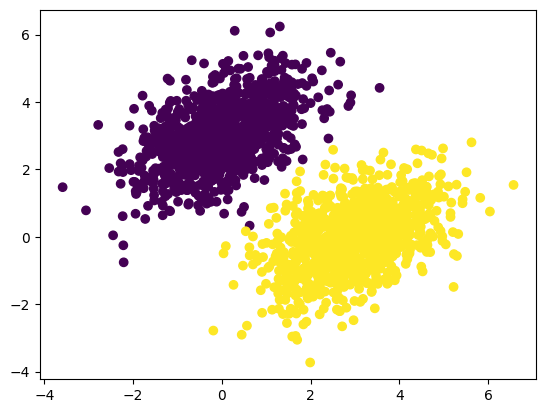

In [3]:
plt.scatter(inputs[:,0], inputs[:,1], c=targets[:,0])
plt.show()

In [5]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

# forward pass
def model(inputs):
  return tf.matmul(inputs, W) + b

# loss: MSE
def square_loss(targets, predictions):
  loss = tf.square(targets - predictions)
  return tf.reduce_mean(loss)

# training step
learning_rate = 0.1
def training_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs)
    loss = square_loss(targets, predictions)
  g_W, g_b = tape.gradient(loss, [W, b])
  W.assign_sub(g_W * learning_rate)
  b.assign_sub(g_b * learning_rate)
  return loss

# epoch
for step in range(40):
  loss = training_step(inputs, targets)
  print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 1.2155
Loss at step 1: 0.0967
Loss at step 2: 0.0847
Loss at step 3: 0.0790
Loss at step 4: 0.0743
Loss at step 5: 0.0701
Loss at step 6: 0.0662
Loss at step 7: 0.0627
Loss at step 8: 0.0594
Loss at step 9: 0.0565
Loss at step 10: 0.0538
Loss at step 11: 0.0513
Loss at step 12: 0.0491
Loss at step 13: 0.0470
Loss at step 14: 0.0452
Loss at step 15: 0.0434
Loss at step 16: 0.0419
Loss at step 17: 0.0404
Loss at step 18: 0.0391
Loss at step 19: 0.0379
Loss at step 20: 0.0368
Loss at step 21: 0.0358
Loss at step 22: 0.0349
Loss at step 23: 0.0340
Loss at step 24: 0.0333
Loss at step 25: 0.0326
Loss at step 26: 0.0319
Loss at step 27: 0.0314
Loss at step 28: 0.0308
Loss at step 29: 0.0303
Loss at step 30: 0.0299
Loss at step 31: 0.0295
Loss at step 32: 0.0291
Loss at step 33: 0.0288
Loss at step 34: 0.0284
Loss at step 35: 0.0282
Loss at step 36: 0.0279
Loss at step 37: 0.0277
Loss at step 38: 0.0274
Loss at step 39: 0.0272


$$
[[w1], [w2]] \cdot [x,y] + b == w1 * x + w2 * y + b = 0.5
\\
y = - w1 / w2 * x + (0.5 - b) / w2
$$

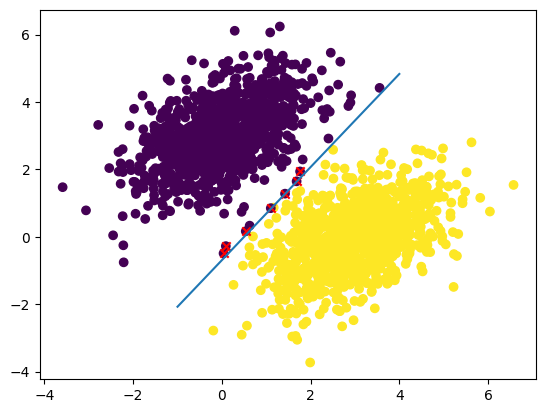

In [15]:
predictions = model(inputs)
mismatched = []
pred = predictions[:,0] > 0.5
for i in range(2 * num_samples_per_class):
  if i < num_samples_per_class:
    if pred[i]:
      mismatched.append(i)
  else:
    if not pred[i]:
      mismatched.append(i)

# classifer line
x = np.linspace(-1, 4, 100)
y = -W[0]/W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y)

# data
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

# mismatched
mx = [inputs[:,0][i] for i in mismatched]
my = [inputs[:,1][i] for i in mismatched]
plt.scatter(mx, my, c='red', marker='x')

plt.show()

# Anatomy of a neural network: core Keras API

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
# compile
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])
# fit
indices_permutation = [int(i) for i in np.random.permutation(len(inputs))]
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]
num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
train_inputs = shuffled_inputs[num_validation_samples:]
train_targets = shuffled_targets[num_validation_samples:]
history = model.fit(train_inputs, train_targets,
                    epochs=5, batch_size=16,
                    validation_data=(val_inputs, val_targets))
print('history', history.history)

# evaluate
loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)
print('loss_and_metrics', loss_and_metrics)

# inference
num_samples_per_class = 1000
neg_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)
pos_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)
new_inputs = np.vstack((neg_samples, pos_samples)).astype(np.float32)
predictions = model(new_inputs) # return tensor
print(predictions[:10])
predictions = model.predict(new_inputs, batch_size=128)
print(predictions[:10]) # return NumPy array


Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9407 - loss: 0.0900 - val_binary_accuracy: 0.9917 - val_loss: 0.0617
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9514 - loss: 0.0726 - val_binary_accuracy: 0.7217 - val_loss: 0.3129
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9557 - loss: 0.0722 - val_binary_accuracy: 0.9900 - val_loss: 0.0445
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9543 - loss: 0.0762 - val_binary_accuracy: 0.9500 - val_loss: 0.1482
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9607 - loss: 0.0746 - val_binary_accuracy: 0.9917 - val_loss: 0.0341
history {'binary_accuracy': [0.9407142996788025, 0.9514285922050476, 0.9557142853736877, 0.954285740852356, 0.9607142806053162], 'loss': [0.0899556577205658, 0.07258094102144241, 0.07223653793334961, 0.07624352723360062, 0.07463159412145615], 'val_binary_accuracy': [0.9916666746139526, 0.721666693687439,